# 11 — Build the feature store

**Objective**: create a single, reusable set of feature tables that every future
model (sales forecasting, churn, CLV, demand forecasting, inventory prediction,
segmentation, recommendations) reads from, instead of each model re-deriving
its own features from analytics or raw tables independently.

**Business context**: without a feature store, five different models each
compute their own "customer recency" or "monthly revenue lags" slightly
differently, and they quietly drift apart over time. A shared feature layer is
the standard fix — Milestone 4 (this one) is a data engineering milestone, not
a modelling one.

**Hard rule for this notebook**: read only from `data/analytics/`, never
`data/raw/`. If a feature can't be built from what's already in the analytics
layer, that's a gap in the analytics layer to flag and fix upstream — not a
reason to reach into raw data from here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 25)
plt.rcParams["figure.figsize"] = (9, 4)

ANALYTICS_DIR = Path("../data/analytics")
FEATURES_DIR = Path("../data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading from : {ANALYTICS_DIR.resolve()}")
print(f"Writing to   : {FEATURES_DIR.resolve()}")

Reading from : /home/claude/project/eaida/data/analytics
Writing to   : /home/claude/project/eaida/data/features


In [2]:
monthly_sales      = pd.read_csv(ANALYTICS_DIR / "monthly_sales.csv")
customer_summary   = pd.read_csv(ANALYTICS_DIR / "customer_summary.csv",
                                  parse_dates=["signup_date", "first_order_date", "last_order_date"])
product_performance = pd.read_csv(ANALYTICS_DIR / "product_performance.csv")
inventory_health   = pd.read_csv(ANALYTICS_DIR / "inventory_health.csv")
store_performance  = pd.read_csv(ANALYTICS_DIR / "store_performance.csv")
daily_sales        = pd.read_csv(ANALYTICS_DIR / "daily_sales.csv", parse_dates=["date"])

for name, df in [("monthly_sales", monthly_sales), ("customer_summary", customer_summary),
                  ("product_performance", product_performance), ("inventory_health", inventory_health),
                  ("store_performance", store_performance), ("daily_sales", daily_sales)]:
    print(f"{name:<22} {len(df):>8,} rows, {len(df.columns)} cols")

monthly_sales                19 rows, 6 cols
customer_summary          5,000 rows, 11 cols
product_performance         200 rows, 8 cols
inventory_health            200 rows, 6 cols
store_performance             8 rows, 7 cols
daily_sales               4,376 rows, 9 cols


## Shared helpers

Same validation pattern as `09_build_analytics_layer.ipynb`, extended with a
`range_checks` option (min/max bounds — e.g. a rate must be between 0 and 1)
and a missing-value report, since the spec asks for both explicitly. Kept as
one shared helper so every feature table is validated identically rather than
four slightly different ad-hoc checks.

In [3]:
validation_results = []  # (table_name, check_name, passed, detail)

def validate_table(table_name: str, df: pd.DataFrame, pk_cols, non_negative_cols=None,
                    range_checks=None, expected_min_rows: int = 1):
    """Standard validation battery for one feature table.

    range_checks: dict of {column: (min, max)}, e.g. {"return_rate": (0, 1)}.
    Missing values are reported (not auto-failed) since some are expected --
    e.g. a customer who never ordered has no recency by definition, not a bug.
    """
    non_negative_cols = non_negative_cols or []
    range_checks = range_checks or {}

    dup_count = df.duplicated(subset=pk_cols).sum()
    validation_results.append((table_name, f"unique primary key {pk_cols}", dup_count == 0, f"{dup_count} duplicate(s)"))

    missing_pk = df[pk_cols].isnull().any(axis=1).sum()
    validation_results.append((table_name, f"no missing primary key {pk_cols}", missing_pk == 0, f"{missing_pk} missing"))

    full_dup = df.duplicated().sum()
    validation_results.append((table_name, "no fully duplicate rows", full_dup == 0, f"{full_dup} duplicate row(s)"))

    for col in non_negative_cols:
        if col in df.columns:
            neg_count = (df[col] < 0).sum()
            validation_results.append((table_name, f"{col} >= 0", neg_count == 0, f"{neg_count} negative row(s)"))

    for col, (lo, hi) in range_checks.items():
        if col in df.columns:
            out_of_range = ((df[col] < lo) | (df[col] > hi)).sum()
            validation_results.append((table_name, f"{col} in [{lo}, {hi}]", out_of_range == 0, f"{out_of_range} out-of-range row(s)"))

    validation_results.append((table_name, f"row count >= {expected_min_rows}", len(df) >= expected_min_rows, f"{len(df)} rows"))

    missing_report = df.isnull().sum()
    missing_report = missing_report[missing_report > 0]
    if len(missing_report):
        print(f"[{table_name}] missing values (reported, not necessarily a failure):")
        print(missing_report.to_string())
    else:
        print(f"[{table_name}] no missing values in any column.")


def save_table(df: pd.DataFrame, filename: str):
    path = FEATURES_DIR / filename
    df.to_csv(path, index=False)
    print(f"Wrote {len(df):,} rows x {len(df.columns)} cols -> {path}")

## 1. Sales forecasting features

**Leakage prevention — read this before touching the code below.**

`monthly_sales.csv`'s last row (2026-07) has only 92 orders vs a normal
~2,000-2,400 — it's a partial month, because data generation stops at
"today". It's dropped here, same convention as `day3_findings.md` /
`day4_findings.md`.

Two of the requested columns are leakage traps **as literally specified**,
and I'm not implementing the naive version:

- **`revenue_growth_rate`** — a naive `(revenue - lag_1_revenue) / lag_1_revenue`
  uses the *current* month's actual revenue. If a downstream model's target is
  "predict this month's revenue," a feature computed FROM this month's revenue
  is the target leaking into its own input. Defined here instead as the growth
  rate between the two most recently *completed* prior months
  (`lag_1_revenue` vs `lag_2_revenue`) — informative, and safe to use as an
  input for predicting the current row's revenue.
- **`moving_average_difference`** — defined here as `rolling_mean_3 -
  rolling_mean_6` (both already lagged, see below), a momentum indicator
  entirely built from history. Not `revenue - rolling_mean_3`, which would
  again mix in the current month's actual revenue.

`rolling_mean_3`, `rolling_mean_6`, `rolling_std_3` are all computed on
`revenue.shift(1)` — i.e. the window covering months t-1..t-3 (or t-1..t-6),
**never including month t's own revenue**. The first 1-6 rows of the dataset
are `NaN` for these columns since there isn't enough history yet — expected,
not a bug, and any model consuming this table needs to either drop those
rows or handle the NaNs explicitly.

`seasonal_index` is included since the spec allows it "if appropriate," but
**with a caveat**: it's computed as each month's revenue divided by the
full-sample average revenue for that calendar month. With only ~18 months of
history (barely 1.5 years), this uses each year's data to describe itself to
some degree — a mild look-ahead risk if used naively in a walk-forward
backtest. The correct fix needs 2+ full years of history to compute
seasonality from strictly prior years; noting it now rather than pretending
this version is leak-free.

In [4]:
sff = monthly_sales.copy()
sff["month"] = pd.PeriodIndex(sff["month"], freq="M")
sff = sff.sort_values("month").reset_index(drop=True)

# Drop the partial current month (data generation stops at "today")
sff = sff.iloc[:-1].copy()

sff["lag_1_revenue"] = sff["revenue"].shift(1)
sff["lag_2_revenue"] = sff["revenue"].shift(2)
sff["lag_3_revenue"] = sff["revenue"].shift(3)

# Rolling stats computed on the SHIFTED series -- never includes the current row's own revenue
shifted = sff["revenue"].shift(1)
sff["rolling_mean_3"] = shifted.rolling(3).mean()
sff["rolling_mean_6"] = shifted.rolling(6).mean()
sff["rolling_std_3"]  = shifted.rolling(3).std()

# Safe (lagged) growth rate: growth between the two most recently COMPLETED months
sff["revenue_growth_rate"] = (sff["lag_1_revenue"] - sff["lag_2_revenue"]) / sff["lag_2_revenue"]

# Momentum indicator built entirely from lagged rolling stats -- no current-month revenue involved
sff["moving_average_difference"] = sff["rolling_mean_3"] - sff["rolling_mean_6"]

sff["month_number"] = sff["month"].dt.month
sff["quarter"] = sff["month"].dt.quarter
sff["year"] = sff["month"].dt.year

# Seasonal index -- full-sample calendar-month average (see markdown caveat above)
monthly_avg_by_calendar_month = sff.groupby("month_number")["revenue"].transform("mean")
sff["seasonal_index"] = (sff["revenue"] / monthly_avg_by_calendar_month).round(4)

sff["month"] = sff["month"].astype(str)
sff = sff[[
    "month", "revenue", "orders", "customers", "units_sold",
    "lag_1_revenue", "lag_2_revenue", "lag_3_revenue",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3",
    "revenue_growth_rate", "month_number", "quarter", "year",
    "moving_average_difference", "seasonal_index",
]]
sff.round(2)

,month,revenue,orders,customers,units_sold,lag_1_revenue,lag_2_revenue,lag_3_revenue,rolling_mean_3,rolling_mean_6,rolling_std_3,revenue_growth_rate,month_number,quarter,year,moving_average_difference,seasonal_index
0,2025-01,621380.65,1265.0,998,3958.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2025,NaN,0.73
1,2025-02,617859.93,1251.0,1004,3941.0,621380.65,NaN,NaN,NaN,NaN,NaN,NaN,2,1,2025,NaN,0.73
2,2025-03,712733.23,1436.0,1113,4560.0,617859.93,621380.65,NaN,NaN,NaN,NaN,-0.01,3,1,2025,NaN,0.75
3,2025-04,682026.66,1463.0,1168,4588.0,712733.23,617859.93,621380.65,650657.94,NaN,53787.60,0.15,4,2,2025,NaN,0.71
4,2025-05,791172.77,1566.0,1222,5008.0,682026.66,712733.23,617859.93,670873.27,NaN,48410.06,-0.04,5,2,2025,NaN,0.82
5,2025-06,794094.12,1592.0,1281,5060.0,791172.77,682026.66,712733.23,728644.22,NaN,56285.77,0.16,6,2,2025,NaN,0.80
6,2025-07,925877.70,1764.0,1374,5704.0,794094.12,791172.77,682026.66,755764.52,703211.23,63875.56,0.00,7,3,2025,52553.29,1.00
7,2025-08,932142.68,1769.0,1396,5773.0,925877.70,794094.12,791172.77,837048.20,753960.74,76942.47,0.17,8,3,2025,83087.46,1.00
8,2025-09,904296.55,1853.0,1447,5756.0,932142.68,925877.70,794094.12,884038.17,806341.19,77956.79,0.01,9,3,2025,77696.97,1.00
9,2025-10,938621.10,1937.0,1556,6153.0,904296.55,932142.68,925877.70,920772.31,838268.41,14608.23,-0.03,10,4,2025,82503.90,1.00


In [5]:
validate_table("sales_forecasting_features", sff, pk_cols=["month"],
               non_negative_cols=["revenue", "orders", "customers", "units_sold"],
               expected_min_rows=12)
save_table(sff, "sales_forecasting_features.csv")

[sales_forecasting_features] missing values (reported, not necessarily a failure):
lag_1_revenue                1
lag_2_revenue                2
lag_3_revenue                3
rolling_mean_3               3
rolling_mean_6               6
rolling_std_3                3
revenue_growth_rate          2
moving_average_difference    6
Wrote 18 rows x 17 cols -> ../data/features/sales_forecasting_features.csv


## 2. Customer features

`customer_summary.csv` already carries most of what's needed from the
analytics layer directly. This section renames/aliases into the RFM
(Recency/Frequency/Monetary) convention multiple models expect, and derives
`purchase_frequency` and `average_days_between_orders`.

**237 customers have never placed a completed order** (signed up, no
purchase yet). For these: `days_since_last_purchase` / `recency` is `NaN`
(there is no "last purchase" to measure from — this is correct, not a
missing-data bug), `average_days_between_orders` is `NaN` (undefined for 0 or
1 orders), and `purchase_frequency` is `0`. A churn or CLV model needs to
treat "never purchased" as its own category, not impute it as an average
recency value — imputing here would quietly turn a legitimate "not yet a
customer" signal into a fabricated one.

In [6]:
cf = customer_summary.copy()

# purchase_frequency: completed orders per 30-day period since signup
cf["purchase_frequency"] = (cf["total_orders"] / (cf["lifetime_days"] / 30)).round(4)

# average_days_between_orders: only defined when there are >= 2 orders to have a gap between
order_span_days = (cf["last_order_date"] - cf["first_order_date"]).dt.days
cf["average_days_between_orders"] = np.where(
    cf["total_orders"] > 1, order_span_days / (cf["total_orders"] - 1), np.nan
).round(2) if False else (order_span_days / (cf["total_orders"] - 1).replace(0, np.nan)).round(2)

# RFM aliases -- several churn/CLV/segmentation models expect these exact names
cf["recency"] = cf["days_since_last_purchase"]
cf["frequency"] = cf["total_orders"]
cf["monetary"] = cf["total_spent"]

cf = cf.rename(columns={"lifetime_days": "customer_lifetime_days"})
cf = cf[[
    "customer_id", "total_orders", "total_spent", "average_order_value", "total_items",
    "first_order_date", "last_order_date", "customer_lifetime_days", "days_since_last_purchase",
    "purchase_frequency", "average_days_between_orders", "recency", "frequency", "monetary", "is_active",
]]
cf.head()

,customer_id,total_orders,total_spent,average_order_value,total_items,first_order_date,last_order_date,customer_lifetime_days,days_since_last_purchase,purchase_frequency,average_days_between_orders,recency,frequency,monetary,is_active
0,1,12.0,3563.83,296.99,41.0,2025-05-18,2026-04-20,1199,72.0,0.3003,30.64,72.0,12.0,3563.83,True
1,2,1.0,515.44,515.44,2.0,2026-06-29,2026-06-29,40,2.0,0.7500,NaN,2.0,1.0,515.44,True
2,3,6.0,2765.29,460.88,20.0,2026-01-28,2026-06-11,159,20.0,1.1321,26.80,20.0,6.0,2765.29,True
3,4,11.0,2492.76,226.61,28.0,2025-01-17,2026-06-05,1179,26.0,0.2799,50.40,26.0,11.0,2492.76,True
4,5,0.0,0.00,0.00,0.0,NaT,NaT,41,NaN,0.0000,NaN,NaN,0.0,0.00,False


In [7]:
validate_table("customer_features", cf, pk_cols=["customer_id"],
               non_negative_cols=["total_orders", "total_spent", "total_items"],
               expected_min_rows=len(customer_summary))
save_table(cf, "customer_features.csv")

[customer_features] missing values (reported, not necessarily a failure):
first_order_date               237
last_order_date                237
days_since_last_purchase       237
average_days_between_orders    598
recency                        237


Wrote 5,000 rows x 15 cols -> ../data/features/customer_features.csv


## 3. Product features

**Known gap in the analytics layer, found while building this table.**

`product_performance.csv` has only an all-time aggregate (`units_sold`,
`revenue`, since the product's first sale). `inventory_health.csv` has a
single `units_sold_last_30_days` snapshot. Neither table stores a
time-indexed product sales history, so `sales_last_90_days` and
`rolling_sales_growth` **cannot be honestly computed from `data/analytics/`
as it exists today** — there's no monthly or daily product-level series to
window over.

Given the "read only from `data/analytics/`" constraint for this milestone,
the correct move is not to reach into `data/raw/order_items.csv` to
reconstruct it here (that would silently violate the boundary this milestone
is supposed to enforce) and not to fabricate a plausible-looking number
either. Both columns are emitted as `NaN` with a `product_features_gap` flag
column, and the real fix is proposed below rather than worked around.

**Proposed fix (for a future analytics-layer milestone)**: add a
`product_monthly_sales.csv` table to `data/analytics/` — one row per
`(product_id, month)` with `units_sold` and `revenue`, built the same way
`daily_sales.csv` already is for stores. Once that table exists, this
notebook's product feature section can compute `sales_last_90_days` as a
trailing 3-month sum and `rolling_sales_growth` as a period-over-period
change, using the exact same lag/rolling pattern already validated above for
`sales_forecasting_features`. This is a data engineering task for the
analytics layer, not something to solve inside the feature store notebook.

In [8]:
pf = product_performance.merge(
    inventory_health[["product_id", "units_sold_last_30_days"]], on="product_id", how="left"
)
pf = pf.rename(columns={"units_sold_last_30_days": "sales_last_30_days"})

# Genuinely unavailable from data/analytics/ as it exists today -- see markdown above.
pf["sales_last_90_days"] = np.nan
pf["rolling_sales_growth"] = np.nan
pf["product_features_gap"] = "sales_last_90_days and rolling_sales_growth require a product_monthly_sales analytics table (not yet built)"

pf = pf[[
    "product_id", "category", "units_sold", "revenue", "average_discount", "average_price",
    "return_rate", "sales_last_30_days", "sales_last_90_days", "rolling_sales_growth",
    "product_features_gap",
]]
pf.head()

,product_id,category,units_sold,revenue,average_discount,average_price,return_rate,sales_last_30_days,sales_last_90_days,rolling_sales_growth,product_features_gap
0,1,Groceries,554,8648.12,0.1371,15.60,0.0090,33,NaN,NaN,sales_last_90_days and rolling_sales_growth re...
1,2,Sporting Goods,554,154144.66,0.1273,278.30,0.0289,37,NaN,NaN,sales_last_90_days and rolling_sales_growth re...
2,3,Home & Kitchen,455,174479.43,0.1360,383.40,0.0242,26,NaN,NaN,sales_last_90_days and rolling_sales_growth re...
3,4,Electronics,542,189094.38,0.1386,348.55,0.0148,44,NaN,NaN,sales_last_90_days and rolling_sales_growth re...
4,5,Sporting Goods,556,121223.97,0.1342,218.59,0.0180,26,NaN,NaN,sales_last_90_days and rolling_sales_growth re...


In [9]:
validate_table("product_features", pf, pk_cols=["product_id"],
               non_negative_cols=["units_sold", "revenue", "sales_last_30_days"],
               range_checks={"return_rate": (0, 1), "average_discount": (0, 1)},
               expected_min_rows=len(product_performance))
save_table(pf, "product_features.csv")

[product_features] missing values (reported, not necessarily a failure):
sales_last_90_days      200
rolling_sales_growth    200
Wrote 200 rows x 11 cols -> ../data/features/product_features.csv


## 4. Store features

`store_performance.csv` gives the all-time aggregate directly. `average_daily_sales`,
`sales_growth`, and `customer_growth` need the time series that only
`daily_sales.csv` has — computed here from the two most recently *completed*
calendar months (excluding the current partial month, same convention as
the forecasting table) to avoid comparing a full month against a partial one,
which would show a fake "decline" every single time this notebook is re-run.

In [10]:
ds = daily_sales.copy()
ds["month"] = ds["date"].dt.to_period("M")
complete_months = sorted(ds["month"].unique())[:-1]  # drop the partial current month
last_month, prev_month = complete_months[-1], complete_months[-2]

store_monthly = ds[ds["month"].isin(complete_months)].groupby(["store_id", "month"]).agg(
    revenue=("revenue", "sum"), customers=("customers", "sum")
).reset_index()

def pct_change_between(df, id_col, value_col, month_from, month_to):
    a = df[df["month"] == month_from].set_index(id_col)[value_col]
    b = df[df["month"] == month_to].set_index(id_col)[value_col]
    return ((b - a) / a.replace(0, np.nan)).round(4)

sales_growth = pct_change_between(store_monthly, "store_id", "revenue", prev_month, last_month).rename("sales_growth")
customer_growth = pct_change_between(store_monthly, "store_id", "customers", prev_month, last_month).rename("customer_growth")

avg_daily_sales = ds.groupby("store_id")["revenue"].mean().round(2).rename("average_daily_sales")

sf = (
    store_performance
    .merge(avg_daily_sales, on="store_id", how="left")
    .merge(sales_growth, on="store_id", how="left")
    .merge(customer_growth, on="store_id", how="left")
)
sf = sf[[
    "store_id", "city", "orders", "customers", "revenue", "average_order_value",
    "return_rate", "average_daily_sales", "sales_growth", "customer_growth",
]]
sf

,store_id,city,orders,customers,revenue,average_order_value,return_rate,average_daily_sales,sales_growth,customer_growth
0,1,Sydney,2686,745,1316570.47,490.16,0.0540,2406.89,0.0962,0.2717
1,2,Sydney,2717,735,1360194.29,500.62,0.0545,2486.64,0.2943,0.2211
2,3,Melbourne,2764,712,1372602.62,496.60,0.0420,2509.33,-0.0971,-0.0991
3,4,Melbourne,2916,724,1475263.77,505.92,0.0484,2697.01,-0.0067,-0.0448
4,5,Brisbane,5711,797,2898607.46,507.55,0.0510,5299.10,0.1382,0.0777
5,6,Perth,5671,786,2847918.95,502.19,0.0515,5206.43,0.0480,-0.0046
6,7,Adelaide,5561,806,2731844.78,491.25,0.0495,4994.23,0.1243,0.0968
7,8,Canberra,5819,793,2893762.76,497.30,0.0514,5290.24,-0.0905,-0.0857


In [11]:
validate_table("store_features", sf, pk_cols=["store_id"],
               non_negative_cols=["orders", "customers", "revenue", "average_daily_sales"],
               range_checks={"return_rate": (0, 1)},
               expected_min_rows=len(store_performance))
save_table(sf, "store_features.csv")

[store_features] no missing values in any column.
Wrote 8 rows x 10 cols -> ../data/features/store_features.csv


## Validation summary — all checks across all four feature tables

In [12]:
validation_df = pd.DataFrame(validation_results, columns=["table", "check", "passed", "detail"])
summary = validation_df.groupby("table")["passed"].agg(total_checks="count", passed_checks="sum").reset_index()
summary["status"] = np.where(summary["total_checks"] == summary["passed_checks"], "PASS", "FAIL")
print(summary[["table", "total_checks", "passed_checks", "status"]].to_string(index=False))

failed = validation_df[~validation_df["passed"]]
if len(failed):
    print("\nFailed checks:")
    print(failed.to_string(index=False))
else:
    print("\nAll validation checks passed across all feature tables.")

                     table  total_checks  passed_checks status
         customer_features             7              7   PASS
          product_features             9              9   PASS
sales_forecasting_features             8              8   PASS
            store_features             9              9   PASS

All validation checks passed across all feature tables.


## Visual checks

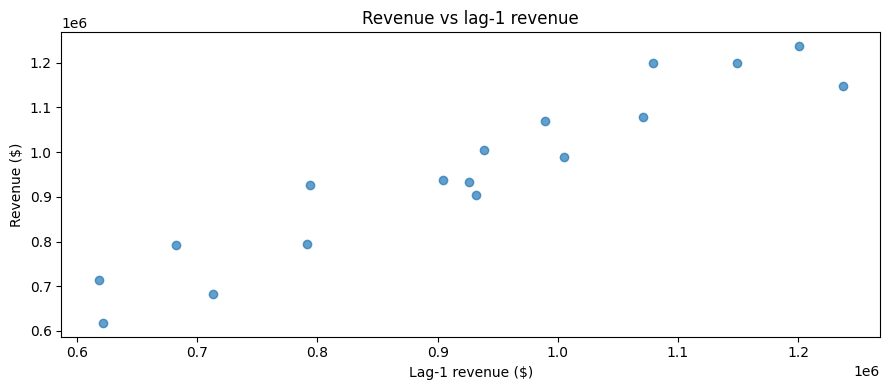

In [13]:
fig, ax = plt.subplots()
ax.scatter(sff["lag_1_revenue"], sff["revenue"], alpha=0.7)
ax.set_title("Revenue vs lag-1 revenue")
ax.set_xlabel("Lag-1 revenue ($)"); ax.set_ylabel("Revenue ($)")
plt.tight_layout(); plt.show()

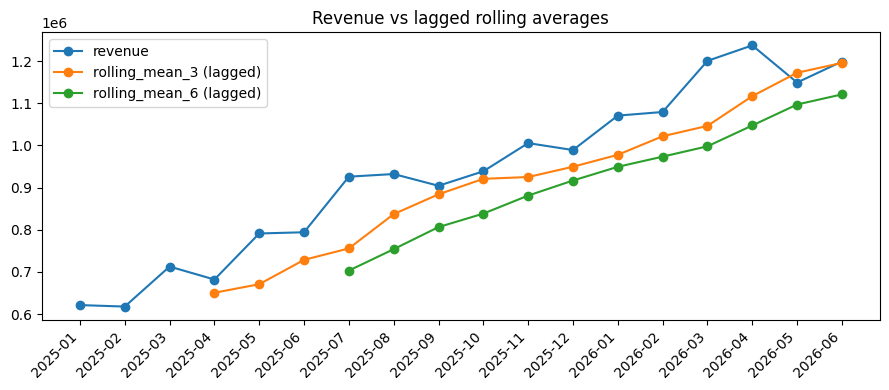

In [14]:
fig, ax = plt.subplots()
x = sff["month"]
ax.plot(x, sff["revenue"], label="revenue", marker="o")
ax.plot(x, sff["rolling_mean_3"], label="rolling_mean_3 (lagged)", marker="o")
ax.plot(x, sff["rolling_mean_6"], label="rolling_mean_6 (lagged)", marker="o")
ax.set_title("Revenue vs lagged rolling averages")
ax.legend(); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

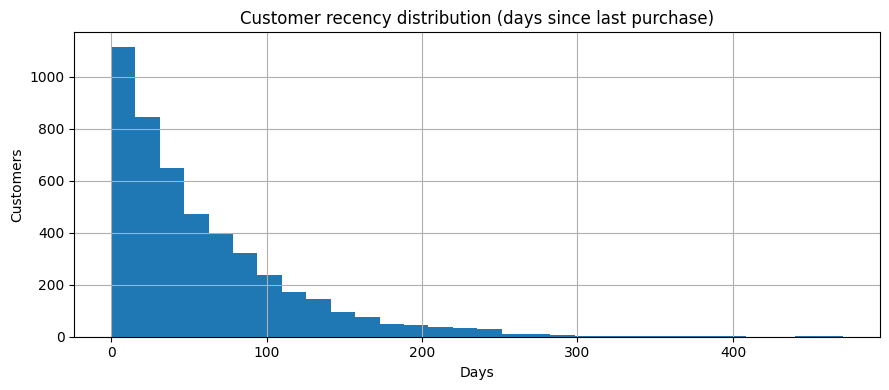

In [15]:
fig, ax = plt.subplots()
cf["recency"].dropna().hist(bins=30, ax=ax)
ax.set_title("Customer recency distribution (days since last purchase)")
ax.set_xlabel("Days"); ax.set_ylabel("Customers")
plt.tight_layout(); plt.show()

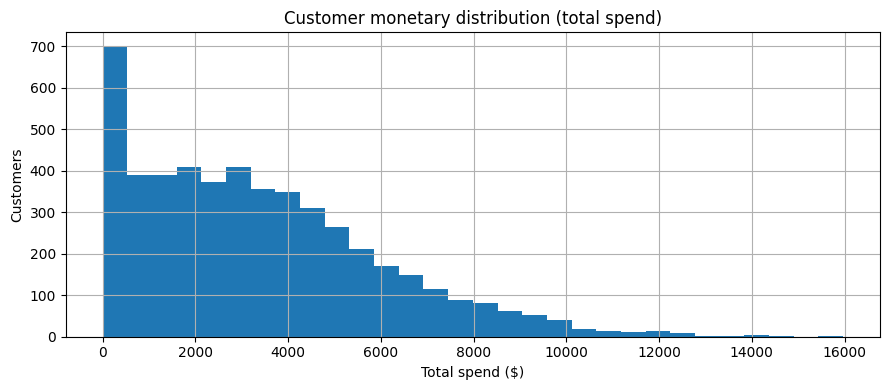

In [16]:
fig, ax = plt.subplots()
cf["monetary"].hist(bins=30, ax=ax)
ax.set_title("Customer monetary distribution (total spend)")
ax.set_xlabel("Total spend ($)"); ax.set_ylabel("Customers")
plt.tight_layout(); plt.show()

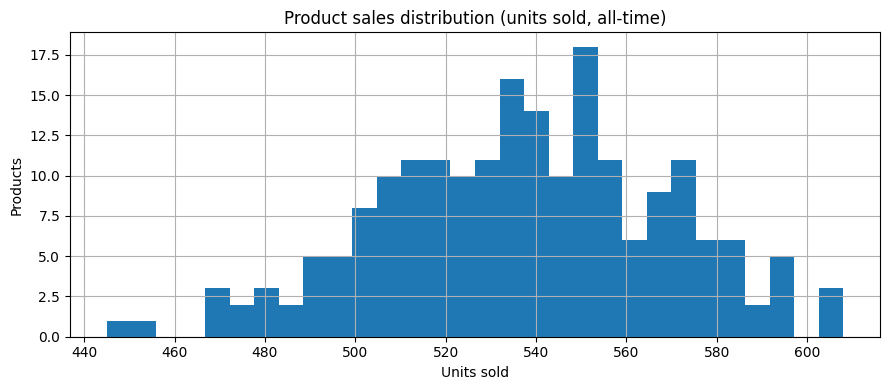

In [17]:
fig, ax = plt.subplots()
pf["units_sold"].hist(bins=30, ax=ax)
ax.set_title("Product sales distribution (units sold, all-time)")
ax.set_xlabel("Units sold"); ax.set_ylabel("Products")
plt.tight_layout(); plt.show()

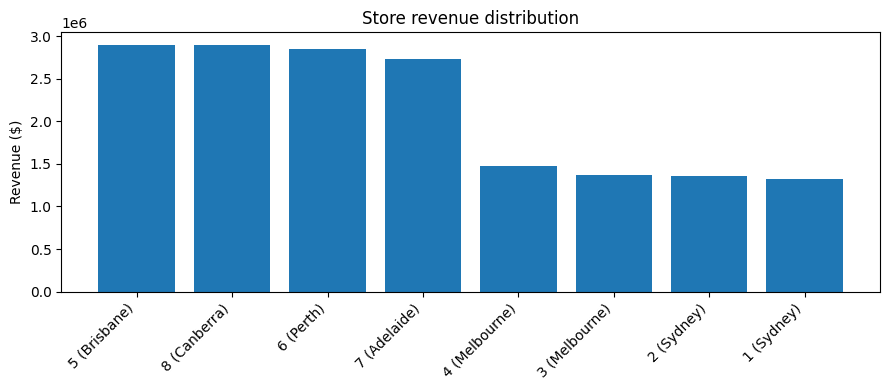

In [18]:
fig, ax = plt.subplots()
sf_sorted = sf.sort_values("revenue", ascending=False)
ax.bar(sf_sorted["store_id"].astype(str) + " (" + sf_sorted["city"] + ")", sf_sorted["revenue"])
ax.set_title("Store revenue distribution")
ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## Final summary

In [19]:
final_summary = pd.DataFrame([
    {"Feature Table": "sales_forecasting_features", "Rows": len(sff), "Columns": len(sff.columns),
     "Validation Status": summary.set_index("table").loc["sales_forecasting_features", "status"]},
    {"Feature Table": "customer_features", "Rows": len(cf), "Columns": len(cf.columns),
     "Validation Status": summary.set_index("table").loc["customer_features", "status"]},
    {"Feature Table": "product_features", "Rows": len(pf), "Columns": len(pf.columns),
     "Validation Status": summary.set_index("table").loc["product_features", "status"]},
    {"Feature Table": "store_features", "Rows": len(sf), "Columns": len(sf.columns),
     "Validation Status": summary.set_index("table").loc["store_features", "status"]},
])
print(final_summary.to_string(index=False))
print(f"\nOutput directory: {FEATURES_DIR.resolve()}")

             Feature Table  Rows  Columns Validation Status
sales_forecasting_features    18       17              PASS
         customer_features  5000       15              PASS
          product_features   200       11              PASS
            store_features     8       10              PASS

Output directory: /home/claude/project/eaida/data/features
